In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import norm

# Fig 2B/C — Neuron-Expressed and Neuron-Specific Interactors

In [2]:
INPUT_FILE = 'Fig2_data.xlsx'
SHEET_EXPRESSED = 'Neuron-expressed'
SHEET_SPECIFIC = 'Neuron-specific'

In [3]:
def bino2test(x1, n1, x2, n2):
    if n1 == 0 or n2 == 0:
        return np.nan
    x1 = float(x1); n1 = float(n1); x2 = float(x2); n2 = float(n2)
    p1 = x1 / n1
    p2 = x2 / n2
    ph = (x1 + x2) / (n1 + n2)
    if ph == 0 or ph == 1:
        return np.nan
    z = abs(p1 - p2) / (ph * (1 - ph) * (1 / n1 + 1 / n2)) ** 0.5
    return 2 * norm.cdf(-z)

def format_pval(pval, pval_star=False, pval_cutoff=0.05, pval_sci=True):
    if not pval_star:
        if pval >= pval_cutoff or pval is None:
            return "n.s."
        return '{:0.1e}'.format(pval) if pval_sci else str(round(pval, 2))
    if pval >= pval_cutoff:
        return "n.s."
    if pval is None or np.isnan(pval):
        return None
    if pval == 0:
        return "***"
    stars = int('{:0.1e}'.format(pval).split("-")[1]) - 1
    return "*" * min(stars, 3)

def plot_barplot(df, y_max, y_step, y_offset_factor, ylabel, dpi=300):
    palette = [sns.color_palette("Pastel1")[0]] + sns.color_palette("Pastel1")[1:6]
    fig, ax = plt.subplots(figsize=(10, 8), dpi=dpi)
    sns.barplot(data=df, x='dataframe', y='fraction_1', palette=palette, linewidth=1, width=0.8, ax=ax)

    for p in ax.patches:
        ax.text(p.get_x() + p.get_width() / 2., p.get_height(), f'{p.get_height():.2f}',
                ha='center', va='bottom', fontsize=20)
    x_coords = [p.get_x() + p.get_width() / 2 for p in ax.patches]
    y_coords = [p.get_height() for p in ax.patches]

    x1_vals = df['Number of Neuron Specific Interactors'].tolist()
    n1_vals = df['Number of Total Interactors'].tolist()
    p_values = []
    for i in range(len(x1_vals)):
        for j in range(i + 1, len(n1_vals)):
            p_values.append(bino2test(x1_vals[i], n1_vals[i], x1_vals[j], n1_vals[j]))

    for j in range(1, len(x_coords)):
        xc1, xc2 = x_coords[0], x_coords[j]
        yc1, yc2 = y_coords[0], y_coords[j]
        y = max(yc1, yc2) + y_offset_factor * j
        ax.plot([xc1, xc2], [y, y], color='k', lw=1.5)
        p_val = p_values.pop(0)
        ax.text((xc1 + xc2) / 2, y, format_pval(p_val, pval_star=True),
                ha='center', va='bottom', color='k', fontsize=20)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('')
    ax.set_ylim(0, y_max)
    ax.set_yticks(range(0, y_step[1] + 1, y_step[0]))
    plt.ylabel(ylabel, fontsize=20)
    ax.legend().remove()
    sns.despine(ax=ax, top=True, right=True)
    plt.tight_layout()
    plt.show()

In [4]:
final_neuron = pd.read_excel(INPUT_FILE, sheet_name=SHEET_EXPRESSED)
final = pd.read_excel(INPUT_FILE, sheet_name=SHEET_SPECIFIC)

/var/folders/zf/l6yy25q51wgch0_2q1h5b2t80000gn/T/ipykernel_14439/3650927256.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='dataframe', y='fraction_1', palette=palette, linewidth=1, width=0.8, ax=ax)
/var/folders/zf/l6yy25q51wgch0_2q1h5b2t80000gn/T/ipykernel_14439/3650927256.py:30: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.barplot(data=df, x='dataframe', y='fraction_1', palette=palette, linewidth=1, width=0.8, ax=ax)
/var/folders/zf/l6yy25q51wgch0_2q1h5b2t80000gn/T/ipykernel_14439/3650927256.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=20)
/var/folders/zf/l6yy25q51wgch0_2q1h5b2t80000gn/T/ipykernel_14

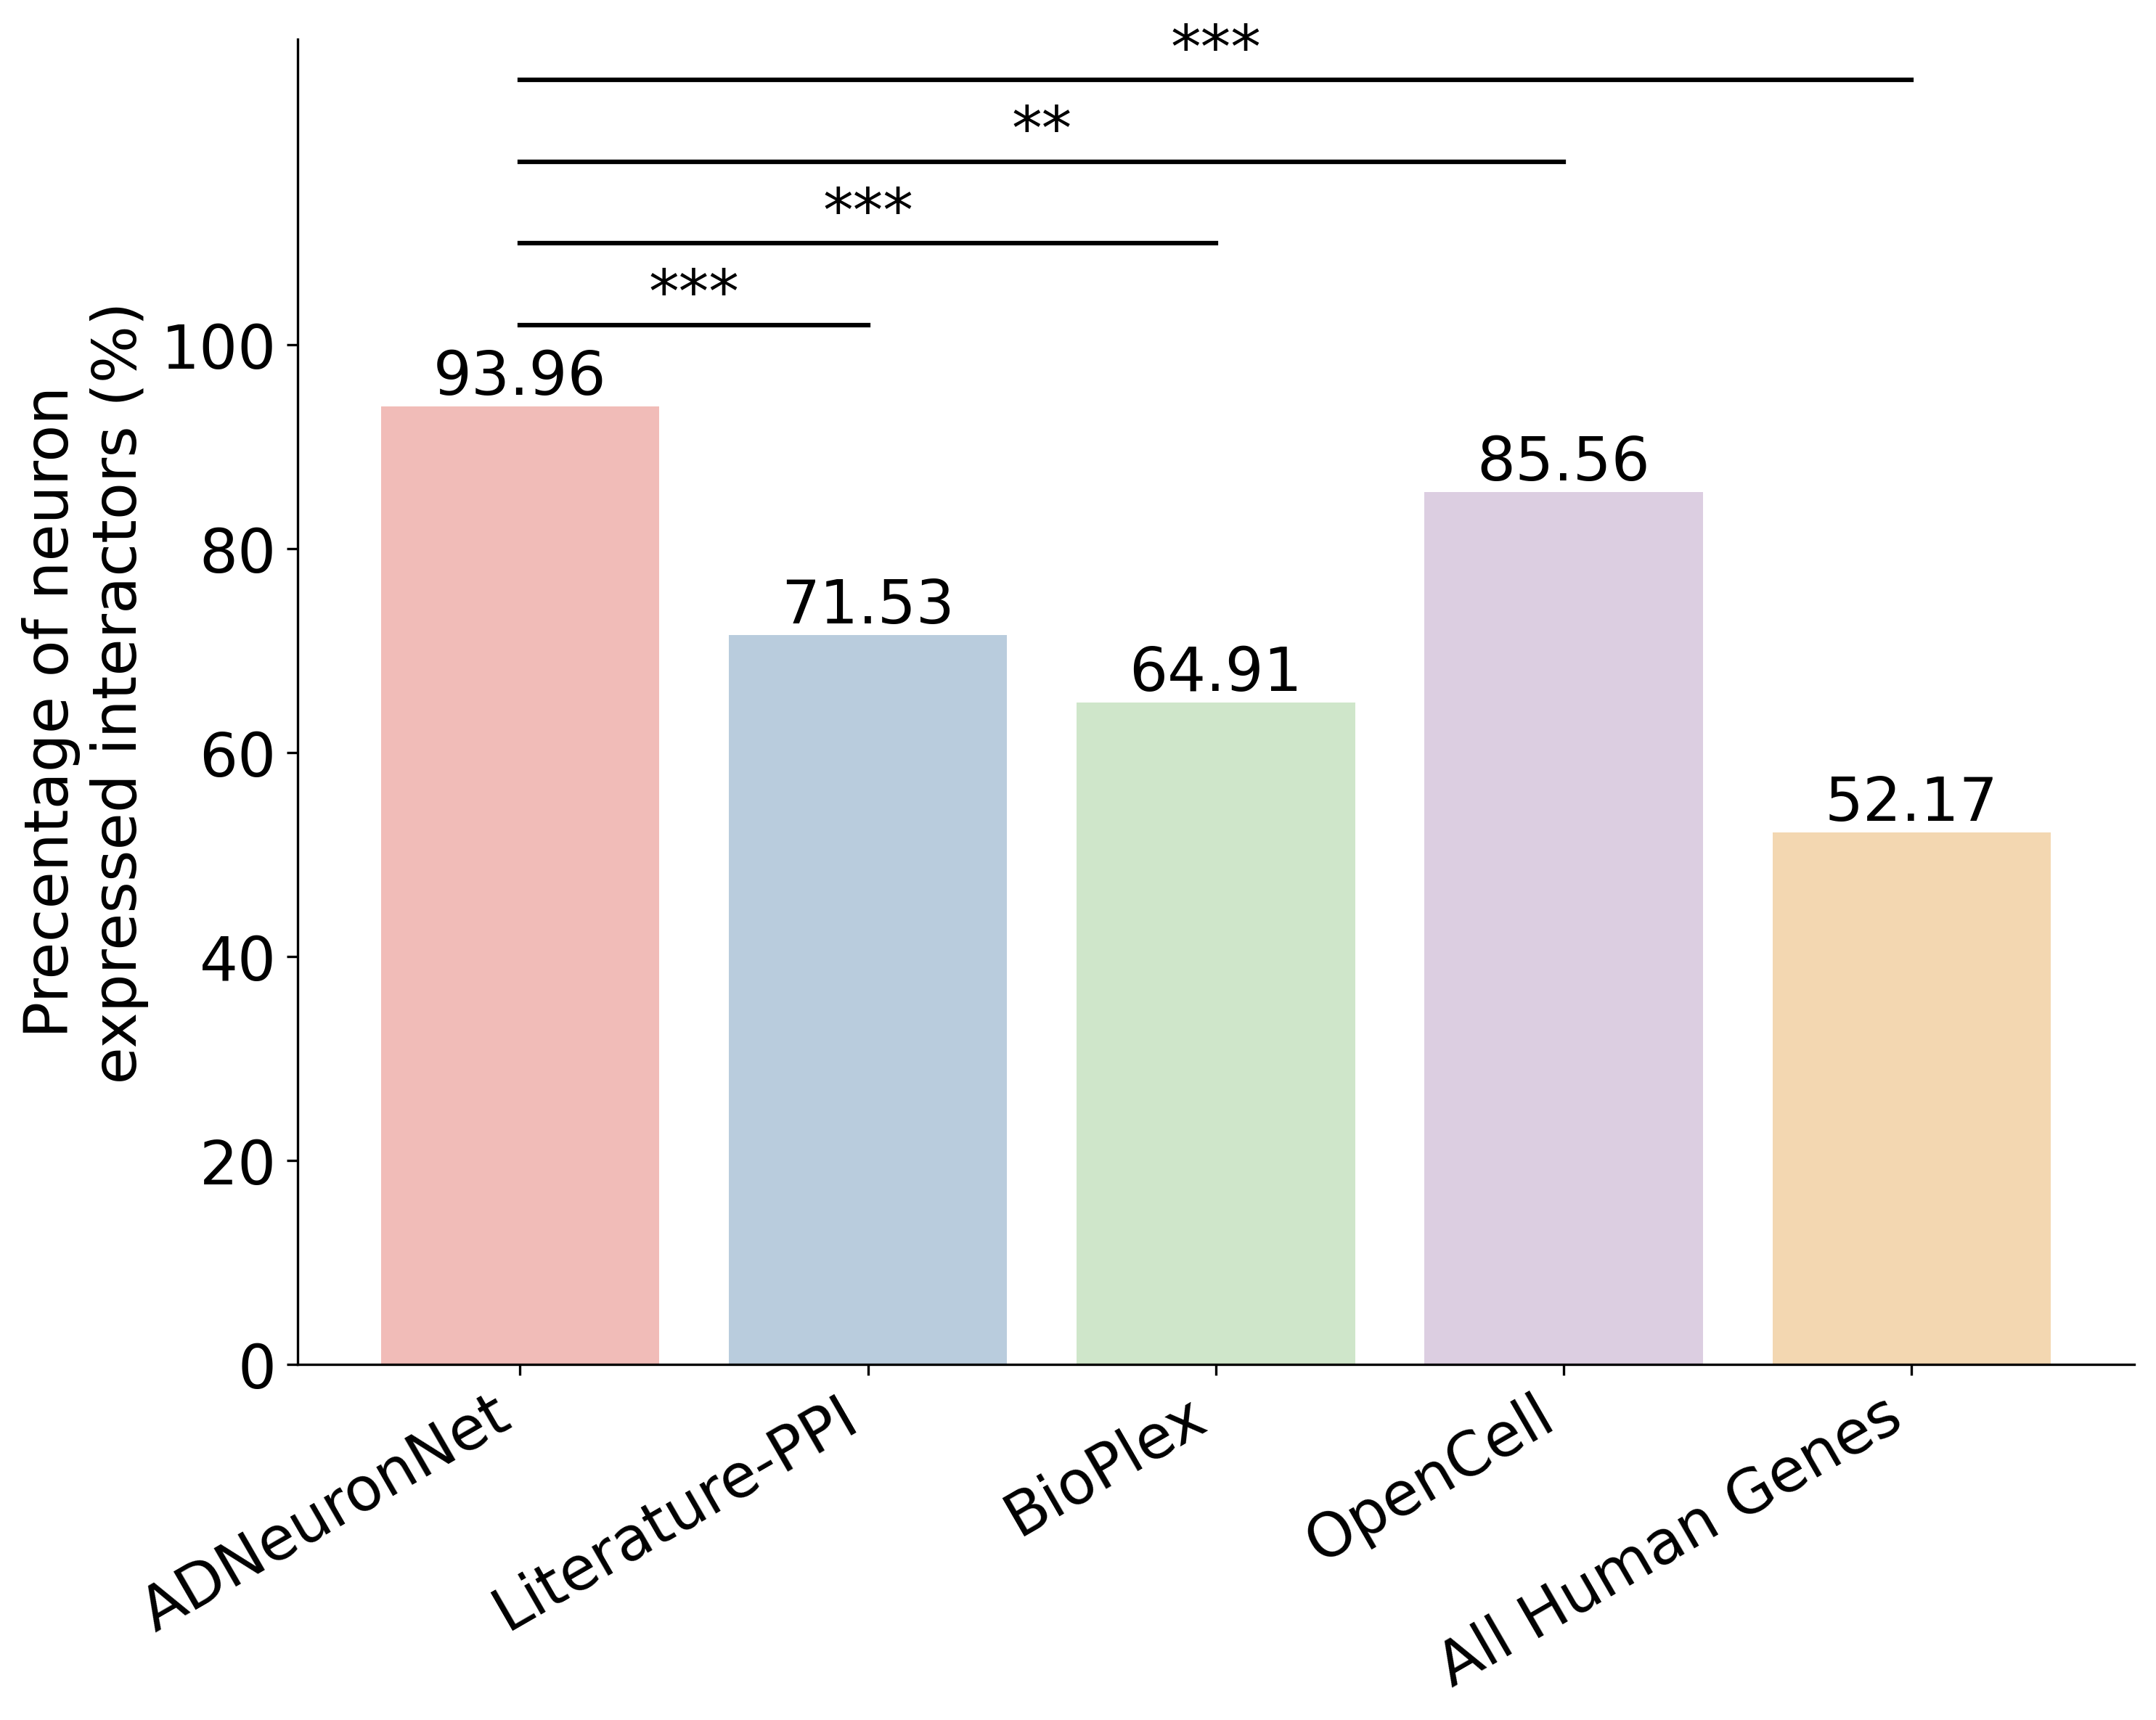

In [5]:
plot_barplot(final_neuron, y_max=130, y_step=(20, 100), y_offset_factor=8,
             ylabel='Precentage of neuron \n expressed interactors (%)')

/var/folders/zf/l6yy25q51wgch0_2q1h5b2t80000gn/T/ipykernel_14439/3650927256.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='dataframe', y='fraction_1', palette=palette, linewidth=1, width=0.8, ax=ax)
/var/folders/zf/l6yy25q51wgch0_2q1h5b2t80000gn/T/ipykernel_14439/3650927256.py:30: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.barplot(data=df, x='dataframe', y='fraction_1', palette=palette, linewidth=1, width=0.8, ax=ax)
/var/folders/zf/l6yy25q51wgch0_2q1h5b2t80000gn/T/ipykernel_14439/3650927256.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=20)
/var/folders/zf/l6yy25q51wgch0_2q1h5b2t80000gn/T/ipykernel_14

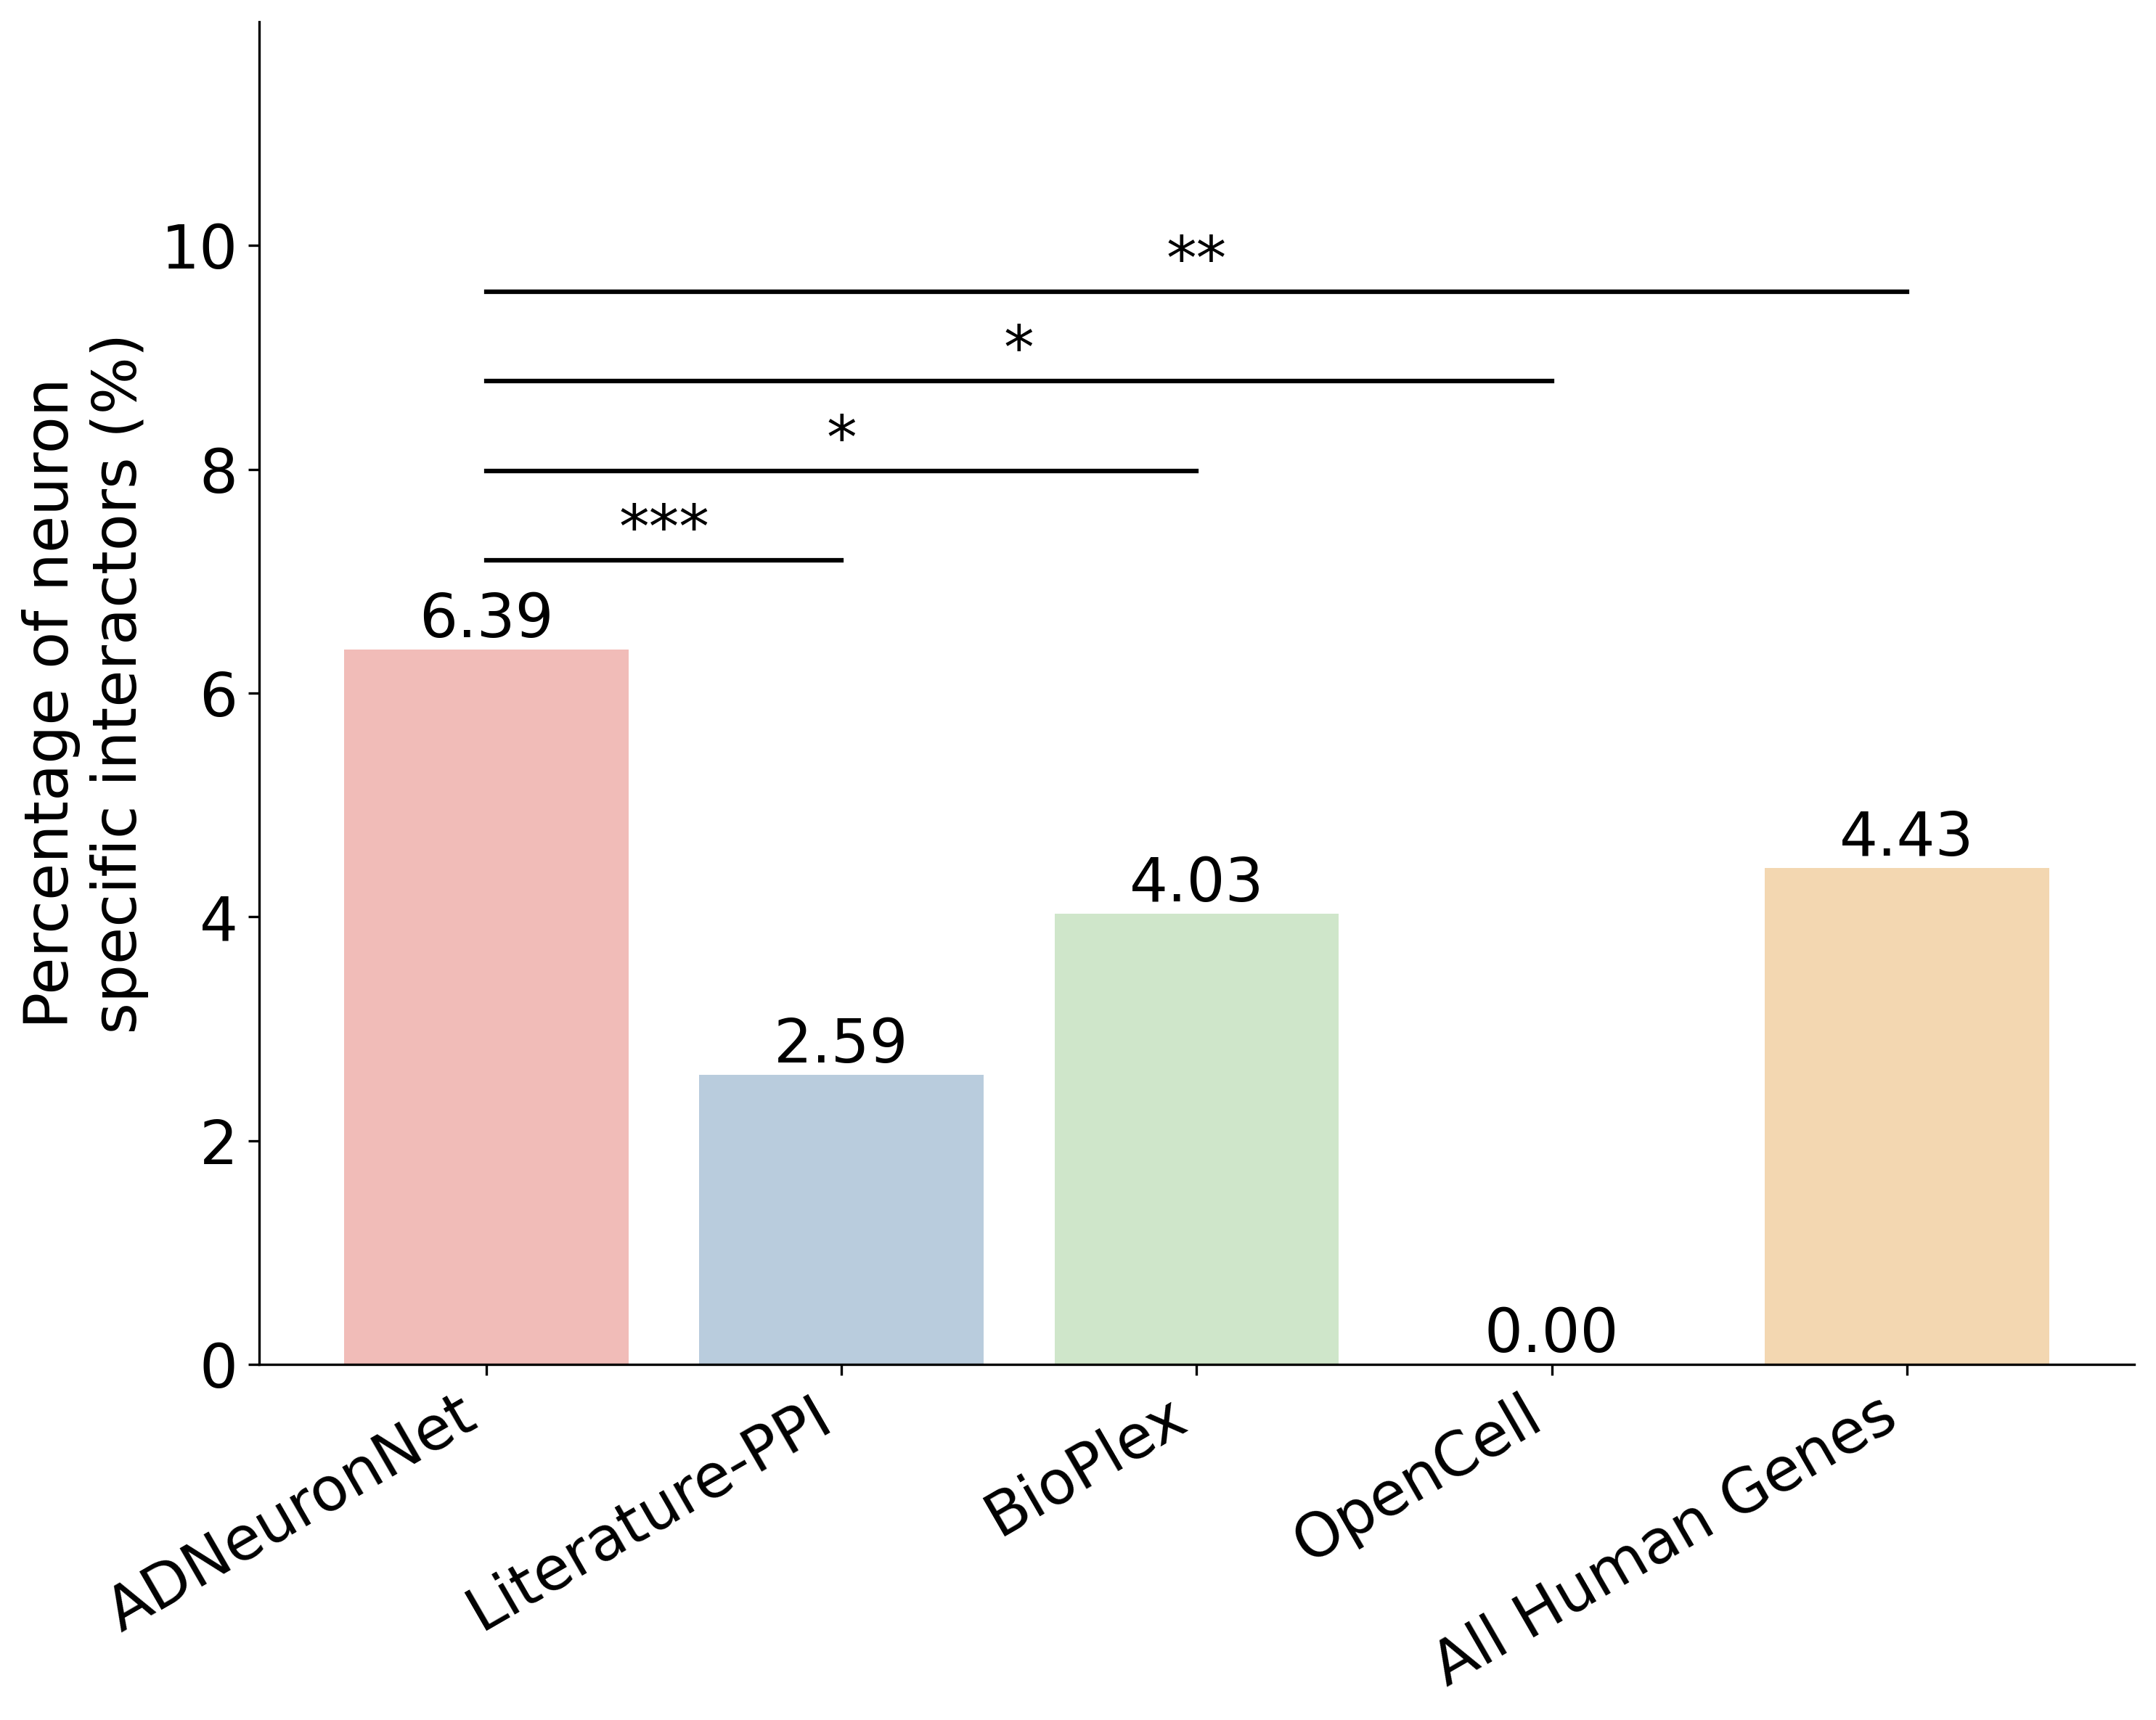

In [6]:
plot_barplot(final, y_max=12, y_step=(2, 10), y_offset_factor=0.8,
             ylabel='Percentage of neuron \n specific interactors (%)')